# Credit Card Customer Churn Prediction
### XGBoost Best Model
---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools, pickle, os, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, roc_curve, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", font_scale=1.1)
os.makedirs("plots", exist_ok=True)
os.makedirs("model", exist_ok=True)
print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv("cc_churn_india.csv")
print("Shape:", df.shape)
print("Churn Rate:", df["Attrition_Flag"].mean().round(4))
df.head()

Shape: (10000, 22)
Churn Rate: 0.242


,CustomerID,CustomerName,Gender,Age,City,Education_Level,Marital_Status,Dependent_Count,Income_Category,Card_Category,...,Total_Revolving_Bal,Avg_Open_To_Buy,Avg_Utilization_Ratio,Months_Inactive_12mon,Contacts_Count_12mon,Total_Trans_Amt_INR,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Total_Amt_Chng_Q4_Q1,Attrition_Flag
0,SBICC100000,Arun Joshi,M,31,Delhi,High School,Married,2,< ₹3 Lakh,Gold,...,212171,126900,0.6296,1,2,147919,58,0.7187,0.9153,1
1,SBICC100001,Priya Reddy,F,61,Delhi,Post-Graduate,Single,2,₹3-6 Lakh,Gold,...,15205,178300,0.1818,1,0,66743,63,0.2772,0.1699,0
2,SBICC100002,Sanjay Iyer,M,34,Bangalore,High School,Single,2,₹6-10 Lakh,Gold,...,40567,247300,0.0000,3,0,59636,71,0.5830,0.5825,0
3,SBICC100003,Kavya Joshi,F,28,Kolkata,Post-Graduate,Married,3,₹10-15 Lakh,Silver,...,15428,83200,0.0193,3,2,122846,73,0.2705,0.7009,0
4,SBICC100004,Sunita Nair,F,42,Bangalore,High School,Single,3,₹6-10 Lakh,Gold,...,169434,224400,0.2560,1,0,11394,68,0.6027,0.7178,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             10000 non-null  str    
 1   CustomerName           10000 non-null  str    
 2   Gender                 10000 non-null  str    
 3   Age                    10000 non-null  int64  
 4   City                   10000 non-null  str    
 5   Education_Level        10000 non-null  str    
 6   Marital_Status         10000 non-null  str    
 7   Dependent_Count        10000 non-null  int64  
 8   Income_Category        10000 non-null  str    
 9   Card_Category          10000 non-null  str    
 10  Months_on_Book         10000 non-null  int64  
 11  Credit_Limit_INR       10000 non-null  int64  
 12  Total_Revolving_Bal    10000 non-null  int64  
 13  Avg_Open_To_Buy        10000 non-null  int64  
 14  Avg_Utilization_Ratio  10000 non-null  float64
 15  Months_Inactiv

In [4]:
df.describe().round(2)

,Age,Dependent_Count,Months_on_Book,Credit_Limit_INR,Total_Revolving_Bal,Avg_Open_To_Buy,Avg_Utilization_Ratio,Months_Inactive_12mon,Contacts_Count_12mon,Total_Trans_Amt_INR,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Total_Amt_Chng_Q4_Q1,Attrition_Flag
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,37.63,1.94,34.71,474888.81,121809.16,352666.57,0.26,2.52,2.17,54329.15,63.90,0.68,0.75,0.24
std,8.88,1.25,15.26,561793.20,185611.47,434930.00,0.18,1.62,1.55,59370.66,8.97,0.30,0.36,0.43
min,19.00,0.00,6.00,43003.00,85.00,10600.00,0.00,0.00,0.00,4109.00,34.00,0.00,0.00,0.00
25%,31.00,1.00,23.00,140522.75,24151.25,100200.00,0.12,1.00,1.00,19165.50,58.00,0.47,0.49,0.00
50%,37.50,2.00,35.00,249424.50,55802.00,178700.00,0.24,2.00,2.00,36246.00,64.00,0.68,0.75,0.00
75%,44.00,3.00,48.00,528855.00,133725.50,402800.00,0.38,4.00,3.00,66420.50,70.00,0.89,0.99,0.00
max,70.00,5.00,56.00,3347914.00,2149094.00,2883700.00,1.00,6.00,6.00,748672.00,99.00,1.89,2.24,1.00


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID               0
CustomerName             0
Gender                   0
Age                      0
City                     0
Education_Level          0
Marital_Status           0
Dependent_Count          0
Income_Category          0
Card_Category            0
Months_on_Book           0
Credit_Limit_INR         0
Total_Revolving_Bal      0
Avg_Open_To_Buy          0
Avg_Utilization_Ratio    0
Months_Inactive_12mon    0
Contacts_Count_12mon     0
Total_Trans_Amt_INR      0
Total_Trans_Ct           0
Total_Ct_Chng_Q4_Q1      0
Total_Amt_Chng_Q4_Q1     0
Attrition_Flag           0
dtype: int64


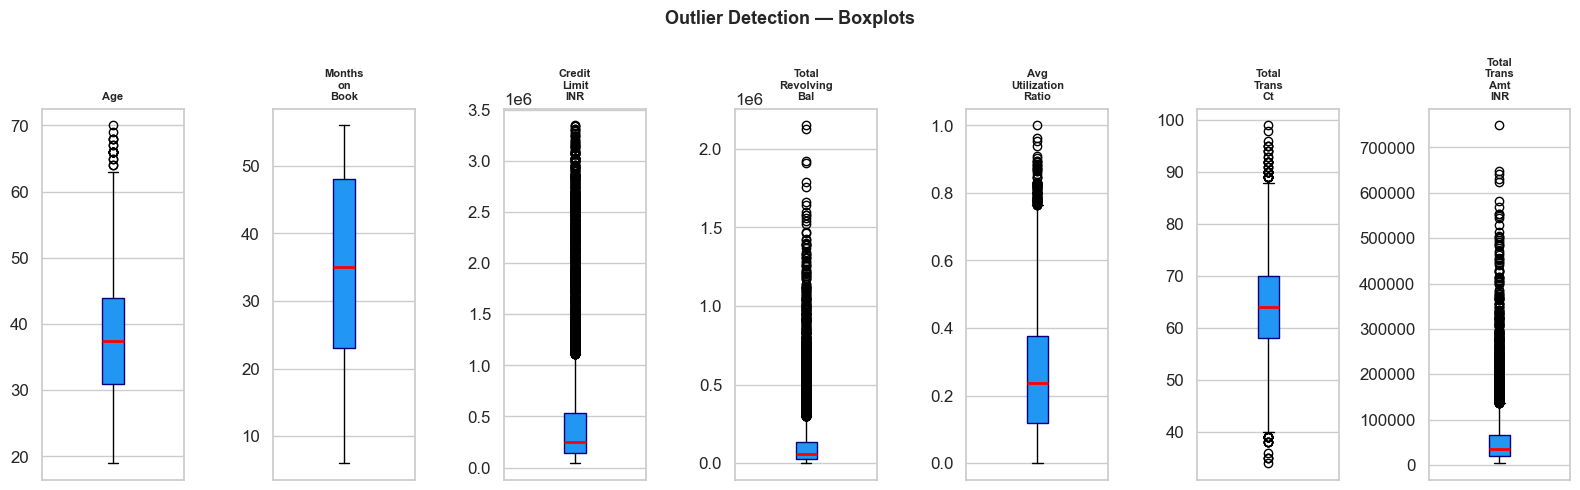

In [6]:
import matplotlib.pyplot as plt

num_cols_plot = ['Age', 'Months_on_Book', 'Credit_Limit_INR', 
                 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 
                 'Total_Trans_Ct', 'Total_Trans_Amt_INR']

fig, axes = plt.subplots(1, 7, figsize=(16, 5))
for ax, col in zip(axes, num_cols_plot):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#2196F3', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_','\n'), fontsize=8, fontweight='bold')
    ax.set_xticks([])
plt.suptitle('Outlier Detection — Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Handling Outliers using IQR
original_num_cols = ['Age', 'Dependent_Count', 'Months_on_Book', 'Credit_Limit_INR',
                     'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Avg_Utilization_Ratio',
                     'Months_Inactive_12mon', 'Contacts_Count_12mon', 'Total_Trans_Amt_INR',
                     'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1']

for col in original_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")

print("\nDecision: Outliers retained — XGBoost is robust to outliers.")

Age: 19 outliers detected
Dependent_Count: 0 outliers detected
Months_on_Book: 0 outliers detected
Credit_Limit_INR: 1013 outliers detected
Total_Revolving_Bal: 1036 outliers detected
Avg_Open_To_Buy: 997 outliers detected
Avg_Utilization_Ratio: 81 outliers detected
Months_Inactive_12mon: 0 outliers detected
Contacts_Count_12mon: 0 outliers detected
Total_Trans_Amt_INR: 705 outliers detected
Total_Trans_Ct: 63 outliers detected
Total_Ct_Chng_Q4_Q1: 24 outliers detected
Total_Amt_Chng_Q4_Q1: 32 outliers detected

Decision: Outliers retained — XGBoost is robust to outliers.


## 3. EDA

### 3.1 Churn Distribution

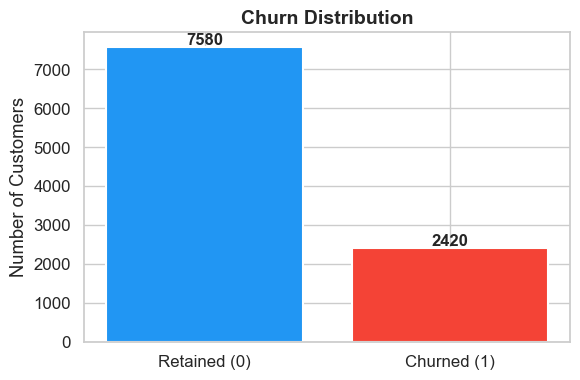

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
vals = df["Attrition_Flag"].value_counts()
bars = ax.bar(["Retained (0)", "Churned (1)"], vals.values,
              color=["#2196F3", "#F44336"], edgecolor="white", linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50,
            str(int(b.get_height())), ha="center", fontweight="bold", fontsize=12)
ax.set_title("Churn Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("plots/1_churn_distribution.png", dpi=150)
plt.show()

### 3.2 Churn Rate by City

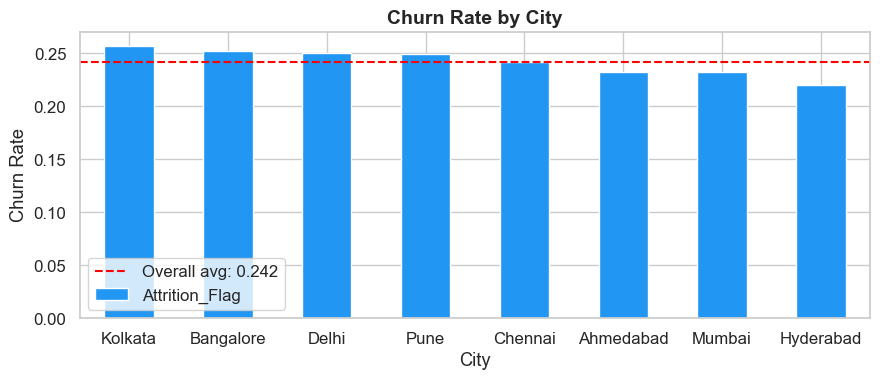

In [9]:
city_churn = df.groupby("City")["Attrition_Flag"].mean().sort_values(ascending=False)
avg = df["Attrition_Flag"].mean()
plt.figure(figsize=(9,4))
city_churn.plot(kind="bar", color="#2196F3", edgecolor="white")
plt.axhline(avg, color="red", ls="--", label="Overall avg: "+str(round(avg,3)))
plt.title("Churn Rate by City", fontsize=14, fontweight="bold")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig("plots/2_churn_by_city.png", dpi=150)
plt.show()

### 3.3 Churn Rate by Card Category

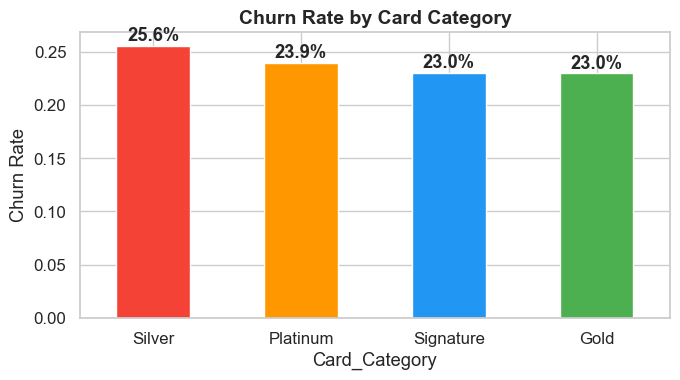

In [10]:
card_churn = df.groupby("Card_Category")["Attrition_Flag"].mean().sort_values(ascending=False)
plt.figure(figsize=(7,4))
card_churn.plot(kind="bar", color=["#F44336","#FF9800","#2196F3","#4CAF50"], edgecolor="white")
plt.title("Churn Rate by Card Category", fontsize=14, fontweight="bold")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
for i, v in enumerate(card_churn.values):
    plt.text(i, v+0.005, str(round(v*100,1))+"%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("plots/3_churn_by_card.png", dpi=150)
plt.show()

### 3.4 Transaction Count by Churn

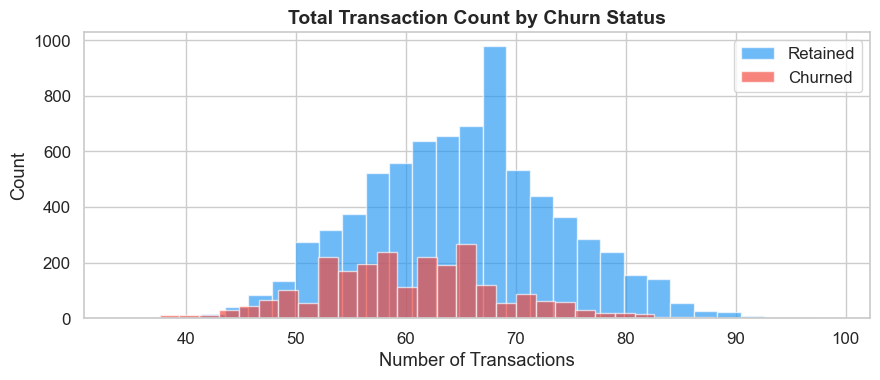

In [11]:
plt.figure(figsize=(9,4))
for label, color, lbl in zip([0,1], ["#2196F3","#F44336"], ["Retained","Churned"]):
    df[df["Attrition_Flag"]==label]["Total_Trans_Ct"].hist(
        bins=30, alpha=0.65, color=color, label=lbl, edgecolor="white")
plt.title("Total Transaction Count by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Number of Transactions")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("plots/4_trans_count_dist.png", dpi=150)
plt.show()

### 3.5 Months Inactive

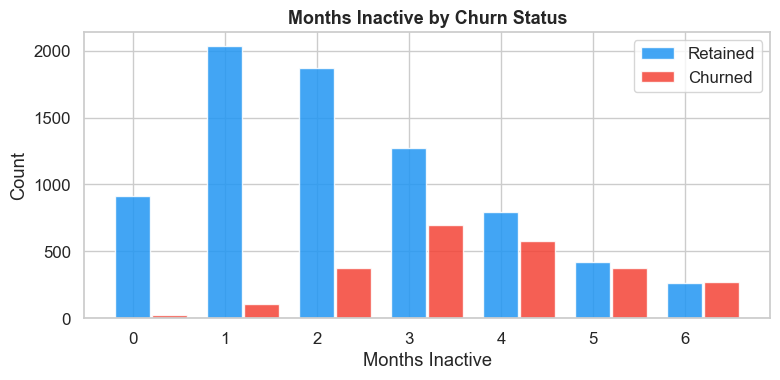

In [12]:
plt.figure(figsize=(8,4))
for label, color, lbl in zip([0,1], ["#2196F3","#F44336"], ["Retained","Churned"]):
    v = df[df["Attrition_Flag"]==label]["Months_Inactive_12mon"].value_counts().sort_index()
    plt.bar(v.index + (0 if label==0 else 0.4), v.values,
            width=0.38, color=color, label=lbl, alpha=0.85)
plt.title("Months Inactive by Churn Status", fontsize=13, fontweight="bold")
plt.xlabel("Months Inactive")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("plots/5_months_inactive.png", dpi=150)
plt.show()

### 3.6 Credit Utilization

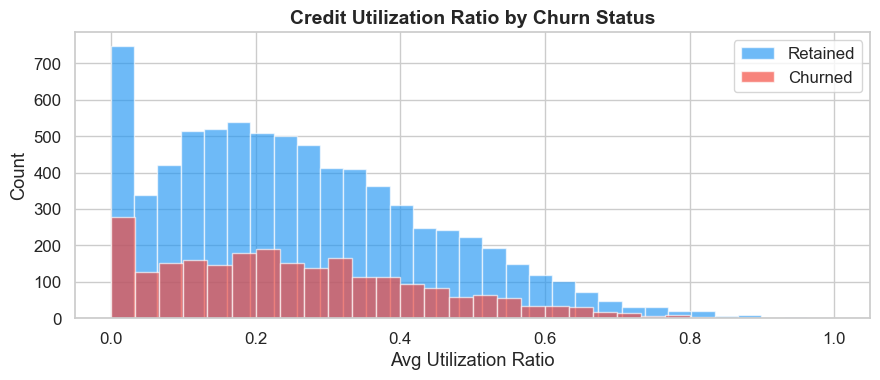

In [13]:
plt.figure(figsize=(9,4))
for label, color, lbl in zip([0,1], ["#2196F3","#F44336"], ["Retained","Churned"]):
    df[df["Attrition_Flag"]==label]["Avg_Utilization_Ratio"].hist(
        bins=30, alpha=0.65, color=color, label=lbl, edgecolor="white")
plt.title("Credit Utilization Ratio by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Avg Utilization Ratio")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("plots/6_utilization_dist.png", dpi=150)
plt.show()

### 3.7 Correlation Heatmap

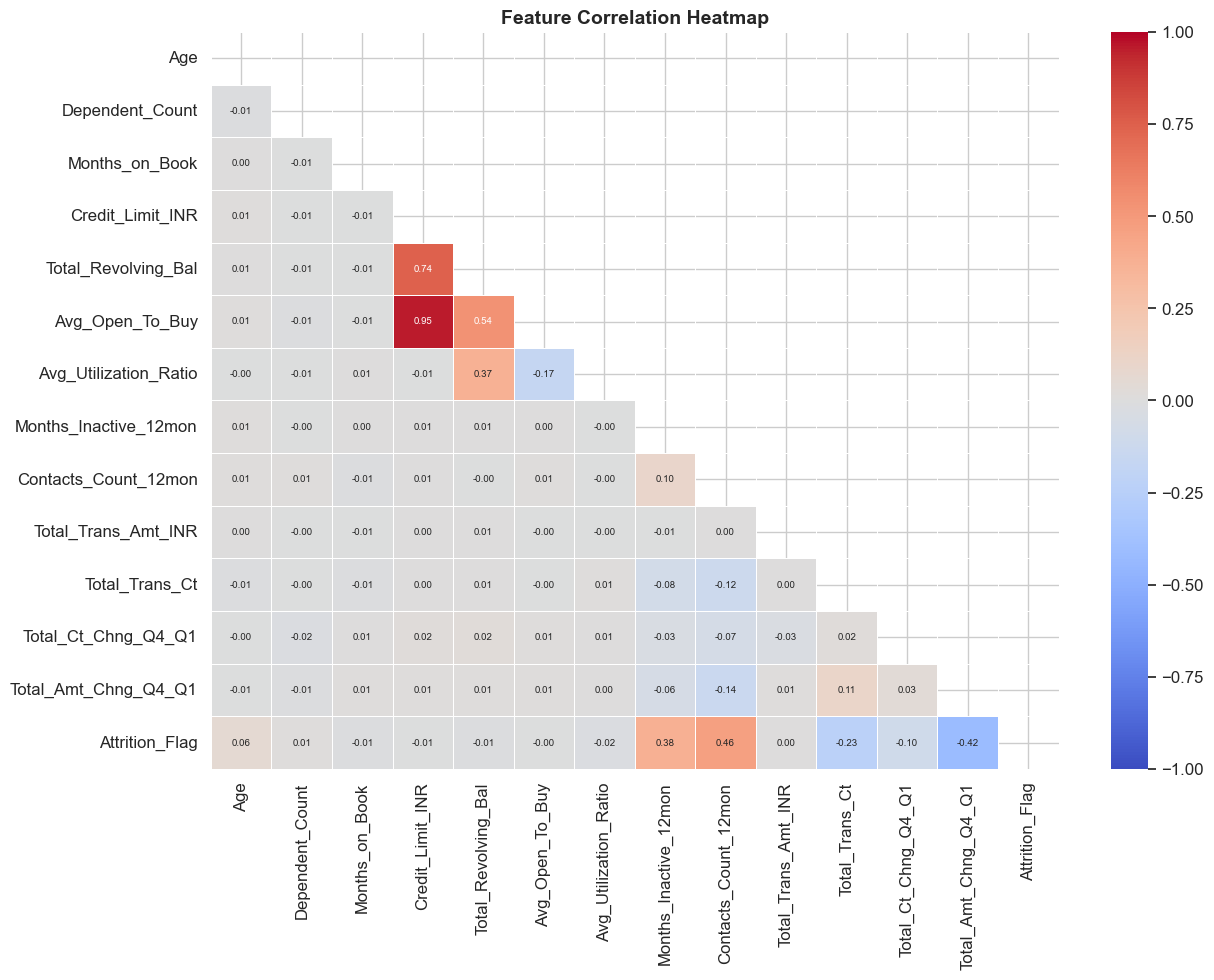

In [14]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()
plt.figure(figsize=(13,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=.4, vmin=-1, vmax=1, annot_kws={"size":7})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/7_correlation_heatmap.png", dpi=150)
plt.show()

## 4. Feature Engineering

In [15]:
df_model = df.copy()
df_model.drop(columns=["CustomerID","CustomerName"], inplace=True)

df_model["spend_per_txn"]         = df_model["Total_Trans_Amt_INR"] / (df_model["Total_Trans_Ct"] + 1)
df_model["util_x_inactive"]       = df_model["Avg_Utilization_Ratio"] * df_model["Months_Inactive_12mon"]
df_model["trans_momentum"]        = df_model["Total_Ct_Chng_Q4_Q1"] * df_model["Total_Amt_Chng_Q4_Q1"]
df_model["revolving_ratio"]       = df_model["Total_Revolving_Bal"] / (df_model["Credit_Limit_INR"] + 1)
df_model["contact_inactive_flag"] = ((df_model["Contacts_Count_12mon"] >= 3) &
                                     (df_model["Months_Inactive_12mon"] >= 2)).astype(int)
df_model["low_trans_flag"]        = (df_model["Total_Trans_Ct"] < 40).astype(int)
df_model["zero_revolving"]        = (df_model["Total_Revolving_Bal"] == 0).astype(int)
df_model["credit_per_month"]      = df_model["Credit_Limit_INR"] / (df_model["Months_on_Book"] + 1)

print("Total features after engineering:", df_model.shape[1] - 1)
df_model.head(3)

Total features after engineering: 27


,Gender,Age,City,Education_Level,Marital_Status,Dependent_Count,Income_Category,Card_Category,Months_on_Book,Credit_Limit_INR,...,Total_Amt_Chng_Q4_Q1,Attrition_Flag,spend_per_txn,util_x_inactive,trans_momentum,revolving_ratio,contact_inactive_flag,low_trans_flag,zero_revolving,credit_per_month
0,M,31,Delhi,High School,Married,2,< ₹3 Lakh,Gold,43,361873,...,0.9153,1,2507.101695,0.6296,0.657826,0.586312,0,0,0,8224.386364
1,F,61,Delhi,Post-Graduate,Single,2,₹3-6 Lakh,Gold,10,222300,...,0.1699,0,1042.859375,0.1818,0.047096,0.068398,0,0,0,20209.090909
2,M,34,Bangalore,High School,Single,2,₹6-10 Lakh,Gold,56,284584,...,0.5825,0,828.277778,0.0000,0.339597,0.142548,0,0,0,4992.701754


## 5. Train / Test Split

In [16]:
X = df_model.drop("Attrition_Flag", axis=1)
y = df_model["Attrition_Flag"]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print("Numeric features   :", len(num_cols))
print("Categorical features:", cat_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

Numeric features   : 21
Categorical features: ['Gender', 'City', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Training samples : 7500
Testing samples  : 2500


## 6. Preprocessing + SMOTE

In [17]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

print("Before SMOTE - Churn rate:", round(y_train.mean(), 4))
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_p, y_train_sm = sm.fit_resample(X_train_p, y_train)
print("After SMOTE  - Churn rate:", round(y_train_sm.mean(), 4))
print("Training shape after SMOTE:", X_train_p.shape)

Before SMOTE - Churn rate: 0.242
After SMOTE  - Churn rate: 0.5
Training shape after SMOTE: (11370, 43)


## 7. Evaluation Function

In [18]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    y_prob       = model.predict_proba(X_test)[:,1]
    print("===== " + name + " - TRAIN =====")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))
    print("===== " + name + " - TEST  =====")
    print(confusion_matrix(y_test, y_test_pred))
    print(classification_report(y_test, y_test_pred))
    print("Train Acc:", round(accuracy_score(y_train, y_train_pred)*100, 2), "%")
    print("Test Acc :", round(accuracy_score(y_test,  y_test_pred)*100,  2), "%")
    print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))
    return y_prob

## 8. Model Training

### 8.1 Logistic Regression

In [19]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_p, y_train_sm)
y_prob_log = evaluate_model(log_model, X_train_p, y_train_sm, X_test_p, y_test, "Logistic Regression")

===== Logistic Regression - TRAIN =====
[[4928  757]
 [ 682 5003]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      5685
           1       0.87      0.88      0.87      5685

    accuracy                           0.87     11370
   macro avg       0.87      0.87      0.87     11370
weighted avg       0.87      0.87      0.87     11370

===== Logistic Regression - TEST  =====
[[1652  243]
 [  91  514]]
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      1895
           1       0.68      0.85      0.75       605

    accuracy                           0.87      2500
   macro avg       0.81      0.86      0.83      2500
weighted avg       0.88      0.87      0.87      2500

Train Acc: 87.34 %
Test Acc : 86.64 %
ROC-AUC  : 0.9346


### 8.2 Random Forest

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_p, y_train_sm)
y_prob_rf = evaluate_model(rf_model, X_train_p, y_train_sm, X_test_p, y_test, "Random Forest")

===== Random Forest - TRAIN =====
[[5685    0]
 [   0 5685]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5685
           1       1.00      1.00      1.00      5685

    accuracy                           1.00     11370
   macro avg       1.00      1.00      1.00     11370
weighted avg       1.00      1.00      1.00     11370

===== Random Forest - TEST  =====
[[1820   75]
 [ 106  499]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1895
           1       0.87      0.82      0.85       605

    accuracy                           0.93      2500
   macro avg       0.91      0.89      0.90      2500
weighted avg       0.93      0.93      0.93      2500

Train Acc: 100.0 %
Test Acc : 92.76 %
ROC-AUC  : 0.9487


### 8.3 Random Forest Tuned

In [21]:
param_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2]
}
rscv_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_rf, n_iter=10, cv=3, scoring="roc_auc", n_jobs=-1, random_state=42
)
rscv_rf.fit(X_train_p, y_train_sm)
best_rf = rscv_rf.best_estimator_
print("Best RF params:", rscv_rf.best_params_)
y_prob_rf_tuned = evaluate_model(best_rf, X_train_p, y_train_sm, X_test_p, y_test, "Random Forest (Tuned)")

Best RF params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 12}
===== Random Forest (Tuned) - TRAIN =====
[[5629   56]
 [ 103 5582]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5685
           1       0.99      0.98      0.99      5685

    accuracy                           0.99     11370
   macro avg       0.99      0.99      0.99     11370
weighted avg       0.99      0.99      0.99     11370

===== Random Forest (Tuned) - TEST  =====
[[1810   85]
 [ 105  500]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1895
           1       0.85      0.83      0.84       605

    accuracy                           0.92      2500
   macro avg       0.90      0.89      0.90      2500
weighted avg       0.92      0.92      0.92      2500

Train Acc: 98.6 %
Test Acc : 92.4 %
ROC-AUC  : 0.9505


### 8.4 Gradient Boosting

In [22]:
gb_model = GradientBoostingClassifier(n_estimators=80, learning_rate=0.15,
                                        max_depth=3, random_state=42)
gb_model.fit(X_train_p, y_train_sm)
y_prob_gb = evaluate_model(gb_model, X_train_p, y_train_sm, X_test_p, y_test, "Gradient Boosting")

===== Gradient Boosting - TRAIN =====
[[5488  197]
 [ 312 5373]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5685
           1       0.96      0.95      0.95      5685

    accuracy                           0.96     11370
   macro avg       0.96      0.96      0.96     11370
weighted avg       0.96      0.96      0.96     11370

===== Gradient Boosting - TEST  =====
[[1806   89]
 [  92  513]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1895
           1       0.85      0.85      0.85       605

    accuracy                           0.93      2500
   macro avg       0.90      0.90      0.90      2500
weighted avg       0.93      0.93      0.93      2500

Train Acc: 95.52 %
Test Acc : 92.76 %
ROC-AUC  : 0.9583


### 8.5 Gradient Boosting Tuned

In [23]:
param_gb = {
    "n_estimators": [300, 400, 500],
    "max_depth": [3],
    "learning_rate": [0.04, 0.05, 0.06],
    "subsample": [0.9, 0.95],
    "min_samples_leaf": [3, 5]
}
rscv_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_gb, n_iter=10, cv=3, scoring="roc_auc", n_jobs=-1, random_state=42
)
rscv_gb.fit(X_train_p, y_train_sm)
best_gb = rscv_gb.best_estimator_
print("Best GB params:", rscv_gb.best_params_)
y_prob_gb_tuned = evaluate_model(best_gb, X_train_p, y_train_sm, X_test_p, y_test, "Gradient Boosting (Tuned)")

Best GB params: {'subsample': 0.9, 'n_estimators': 500, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.05}
===== Gradient Boosting (Tuned) - TRAIN =====
[[5545  140]
 [ 244 5441]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5685
           1       0.97      0.96      0.97      5685

    accuracy                           0.97     11370
   macro avg       0.97      0.97      0.97     11370
weighted avg       0.97      0.97      0.97     11370

===== Gradient Boosting (Tuned) - TEST  =====
[[1808   87]
 [  96  509]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1895
           1       0.85      0.84      0.85       605

    accuracy                           0.93      2500
   macro avg       0.90      0.90      0.90      2500
weighted avg       0.93      0.93      0.93      2500

Train Acc: 96.62 %
Test Acc : 92.68 %
ROC-AUC  : 0.9586


### 8.6 XGBoost

In [24]:
xgb_model = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                          subsample=0.9, colsample_bytree=0.9,
                          eval_metric="auc", random_state=42, n_jobs=-1)
xgb_model.fit(X_train_p, y_train_sm)
y_prob_xgb = evaluate_model(xgb_model, X_train_p, y_train_sm, X_test_p, y_test, "XGBoost")

===== XGBoost - TRAIN =====
[[5559  126]
 [ 261 5424]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5685
           1       0.98      0.95      0.97      5685

    accuracy                           0.97     11370
   macro avg       0.97      0.97      0.97     11370
weighted avg       0.97      0.97      0.97     11370

===== XGBoost - TEST  =====
[[1805   90]
 [  94  511]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1895
           1       0.85      0.84      0.85       605

    accuracy                           0.93      2500
   macro avg       0.90      0.90      0.90      2500
weighted avg       0.93      0.93      0.93      2500

Train Acc: 96.6 %
Test Acc : 92.64 %
ROC-AUC  : 0.959


### 8.7 XGBoost Tuned

In [25]:
param_xgb = {
    "n_estimators": [400, 500, 600],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.04, 0.05],
    "subsample": [0.9, 0.95],
    "colsample_bytree": [0.95, 1.0]
}
rscv_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric="auc", random_state=42, n_jobs=-1),
    param_xgb, n_iter=10, cv=3, scoring="roc_auc", n_jobs=-1, random_state=42
)
rscv_xgb.fit(X_train_p, y_train_sm)
best_xgb = rscv_xgb.best_estimator_
print("Best XGB params:", rscv_xgb.best_params_)
y_prob_xgb_tuned = evaluate_model(best_xgb, X_train_p, y_train_sm, X_test_p, y_test, "XGBoost (Tuned)")

Best XGB params: {'subsample': 0.9, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.95}
===== XGBoost (Tuned) - TRAIN =====
[[5569  116]
 [ 238 5447]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5685
           1       0.98      0.96      0.97      5685

    accuracy                           0.97     11370
   macro avg       0.97      0.97      0.97     11370
weighted avg       0.97      0.97      0.97     11370

===== XGBoost (Tuned) - TEST  =====
[[1814   81]
 [  96  509]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1895
           1       0.86      0.84      0.85       605

    accuracy                           0.93      2500
   macro avg       0.91      0.90      0.90      2500
weighted avg       0.93      0.93      0.93      2500

Train Acc: 96.89 %
Test Acc : 92.92 %
ROC-AUC  : 0.9604


## 9. Results & Visualizations

### 9.1 Model Accuracy Comparison

Best Model: XGBoost (Tuned) | ROC-AUC: 0.9604


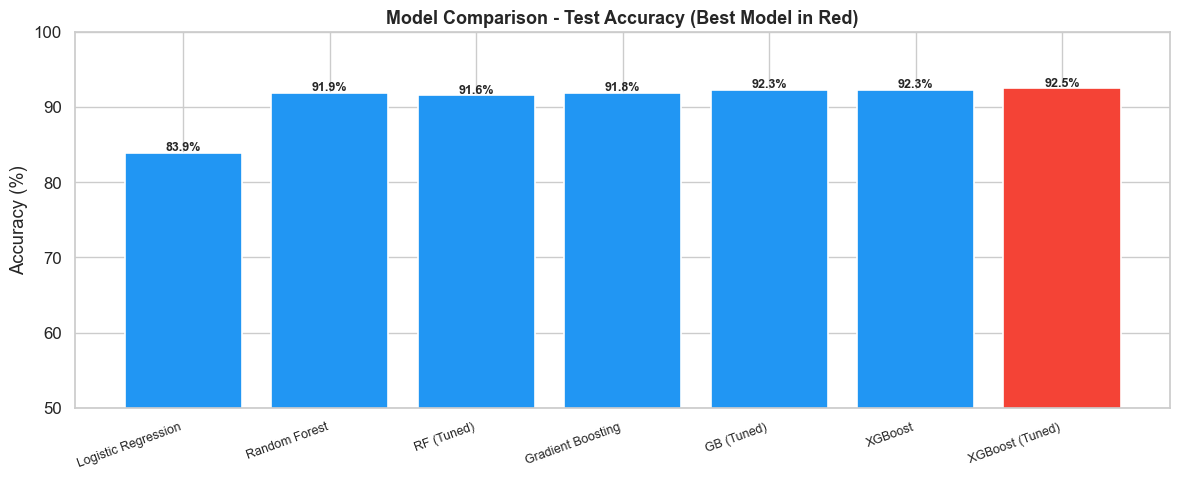

              Model Test Accuracy  ROC-AUC  F1-Score
Logistic Regression        83.88%   0.9346    0.7268
      Random Forest        91.88%   0.9487    0.8375
         RF (Tuned)        91.56%   0.9505    0.8332
  Gradient Boosting        91.84%   0.9583    0.8371
         GB (Tuned)        92.28%   0.9586    0.8440
            XGBoost        92.28%   0.9590    0.8435
    XGBoost (Tuned)        92.48%   0.9604    0.8474


In [26]:
model_names = ["Logistic Regression","Random Forest","RF (Tuned)",
               "Gradient Boosting","GB (Tuned)","XGBoost","XGBoost (Tuned)"]
all_probs   = [y_prob_log, y_prob_rf, y_prob_rf_tuned,
               y_prob_gb, y_prob_gb_tuned, y_prob_xgb, y_prob_xgb_tuned]

aucs      = [roc_auc_score(y_test, p) for p in all_probs]
best_idx  = int(np.argmax(aucs))
best_name = model_names[best_idx]
print("Best Model:", best_name, "| ROC-AUC:", round(aucs[best_idx], 4))

test_accs = [accuracy_score(y_test, (p>=0.4).astype(int))*100 for p in all_probs]
colors    = ["#F44336" if i == best_idx else "#2196F3" for i in range(len(model_names))]

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(model_names, test_accs, color=colors, edgecolor="white", linewidth=1.2)
for b, v in zip(bars, test_accs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            str(round(v,1))+"%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Model Comparison - Test Accuracy (Best Model in Red)", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(50, 100)
ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("plots/8_model_comparison.png", dpi=150)
plt.show()

results_df = pd.DataFrame({
    "Model": model_names,
    "Test Accuracy": [str(round(a,2))+"%" for a in test_accs],
    "ROC-AUC": [round(a, 4) for a in aucs],
    "F1-Score": [round(f1_score(y_test, (p>=0.4).astype(int)), 4) for p in all_probs]
})
print(results_df.to_string(index=False))

### 9.2 ROC Curves

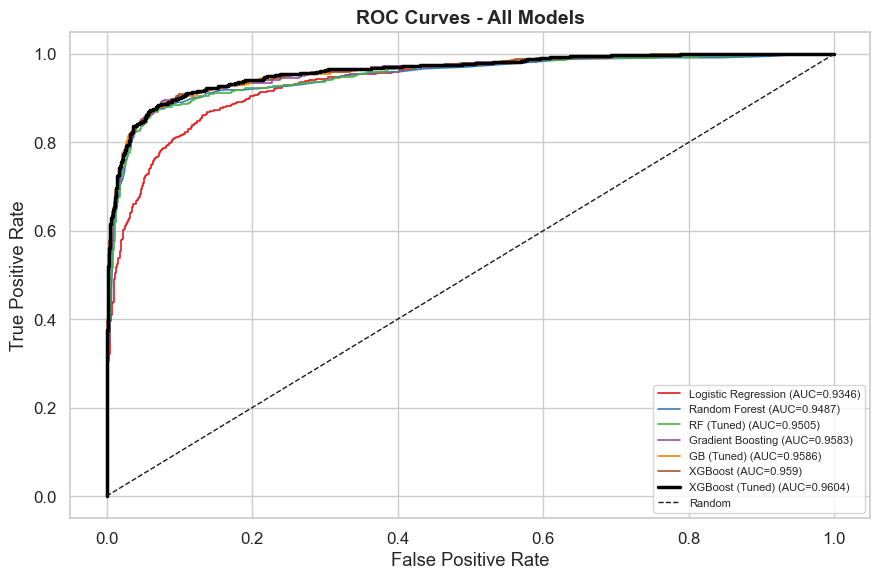

In [27]:
plt.figure(figsize=(9,6))
colors_roc = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00","#a65628","#000000"]
for nm, prob, color in zip(model_names, all_probs, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    lw = 2.5 if "XGBoost (Tuned)" in nm else 1.2
    plt.plot(fpr, tpr, lw=lw, color=color, label=nm+" (AUC="+str(round(auc,4))+")")
plt.plot([0,1],[0,1],"k--",lw=1,label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models", fontsize=14, fontweight="bold")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("plots/9_roc_curves.png", dpi=150)
plt.show()

### 9.3 Confusion Matrix - XGBoost Best Model

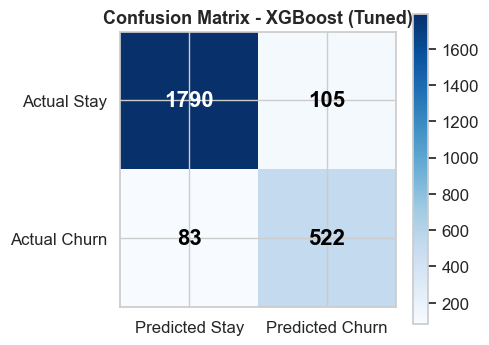

In [28]:
best_prob   = all_probs[best_idx]
y_pred_best = (best_prob >= 0.4).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_title("Confusion Matrix - " + best_name, fontsize=13, fontweight="bold")
for i, j in itertools.product(range(2), range(2)):
    ax.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=16,
            color="white" if cm[i,j]>cm.max()//2 else "black", fontweight="bold")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Predicted Stay","Predicted Churn"])
ax.set_yticklabels(["Actual Stay","Actual Churn"])
plt.tight_layout()
plt.savefig("plots/10_confusion_matrix.png", dpi=150)
plt.show()

### 9.4 Feature Importance - XGBoost

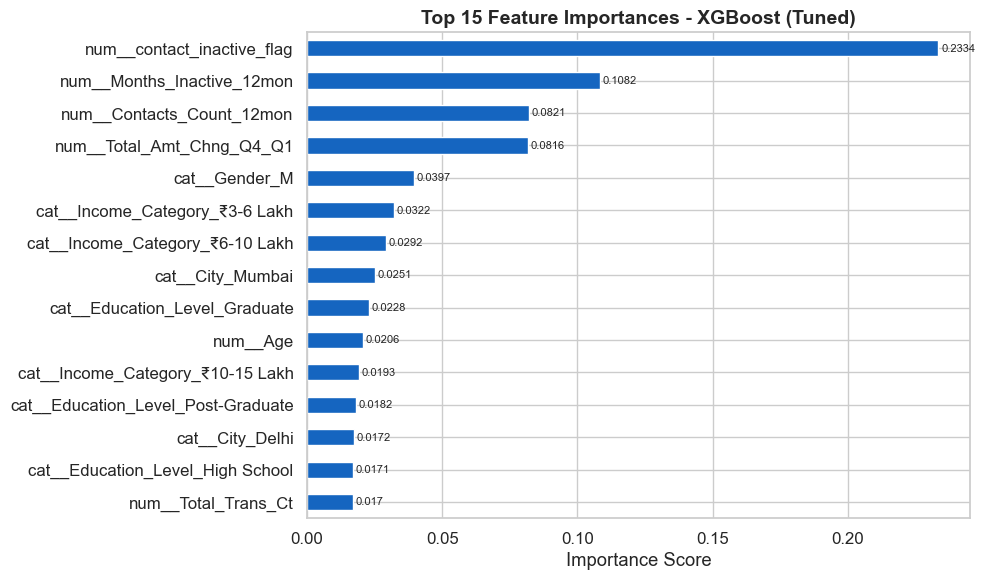

In [29]:
best_model  = [log_model, rf_model, best_rf, gb_model, best_gb, xgb_model, best_xgb][best_idx]
feat_names  = preprocessor.get_feature_names_out()

if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=feat_names).nlargest(15)
    fig, ax = plt.subplots(figsize=(10,6))
    fi[::-1].plot(kind="barh", ax=ax, color="#1565C0", edgecolor="white")
    ax.set_title("Top 15 Feature Importances - " + best_name, fontsize=14, fontweight="bold")
    ax.set_xlabel("Importance Score")
    for i, v in enumerate(fi[::-1].values):
        ax.text(v+0.001, i, str(round(v,4)), va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("plots/11_feature_importance.png", dpi=150)
    plt.show()
else:
    print(best_name, "does not support feature importances directly.")

## 10. Save Best Model

In [30]:
print("Best Model:", best_name)
print("Test Accuracy :", round(accuracy_score(y_test, y_pred_best)*100, 2), "%")
print("ROC-AUC       :", round(roc_auc_score(y_test, best_prob), 4))
print("F1-Score      :", round(f1_score(y_test, y_pred_best), 4))

with open("model/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("model/scaler.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print("Model saved to model/best_model.pkl")
print("Scaler saved to model/scaler.pkl")

Best Model: XGBoost (Tuned)
Test Accuracy : 92.48 %
ROC-AUC       : 0.9604
F1-Score      : 0.8474
Model saved to model/best_model.pkl
Scaler saved to model/scaler.pkl
